# Can local Clef replace a frontier LLM judge?

A local judge avoids a hosted inference bill, but that only helps if its verdicts are useful. We compare Ollama-hosted Clef (Q4_K_M) with Claude Opus 5.5 and Sonnet 5.5 through Snowflake Cortex on **factual consistency of fixed summaries**. We are evaluating the judges, not asking them to generate summaries.

## What this run found

**Clef was repeatable, but it was not faster at the median or as closely aligned with human ratings. Lower total cost remains unproven.**

| Question | Finding in the saved run |
| --- | --- |
| Is Clef cheaper? | No provider API charge for local inference. Cortex dollar charges and local hardware/electricity costs were not measured, so we cannot claim lower total cost. |
| Is Clef faster? | Median 4.55 s, versus Opus 3.40 s and Sonnet 2.45 s. Clef's p95 was better than Opus's, but worse than Sonnet's. |
| Does Clef agree with humans? | MAE 0.134, versus Opus 0.087 and Sonnet 0.089. Lower is better; the hosted judges were closer on this task. |
| Is Clef well-calibrated? | Not across the observed score range. For example, its first-trial 0.7-0.8 bin averaged 0.746 while experts averaged 0.990. |
| Is Clef repeatable? | Identical scores in the 81 complete shared three-trial cohorts. Consistency across calls does not imply correctness. |

These findings describe the **bundled October 8, 2026 snapshot**: 100 held-out summaries from 20 articles, three trials per judge, 900 scheduled judgments. Quality comparisons use 281 successful matched example/trial pairs; latency uses each judge's successful measured calls. Failures and the different denominators are explained below. This is a task-specific comparison, not a general model leaderboard.

Read on for the evidence, calibration interpretation, and deployment recommendation. Replaying with `RUN_LIVE = False` makes no model calls. The optional live cells collect a new paid run; **the written results are fixed commentary on the bundled snapshot and must be revised if you run new measurements**.

TruLens `Metric`, `Jury.repeated`, `AlignmentReport`, `CrossModelAlignmentReport`, and `Jury` handle scoring, repeatability, and alignment diagnostics. Two small adapters supply the Ollama System One and Cortex Messages transports.

In [ ]:
import json
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
from trulens.benchmark import AlignmentReport
from trulens.benchmark.cross_model_alignment import CrossModelAlignmentReport
from trulens.core import Metric
from trulens.feedback import Jury

RUN_LIVE = False
N_EXAMPLES = 100
N_TRIALS = 3
THRESHOLD = 0.75

example_dir = Path.cwd()
if example_dir.name != "clef_judge_comparison":
    example_dir /= (
        "examples/expositional/models/local_and_OSS_models/"
        "clef_judge_comparison"
    )
snapshot_path = example_dir / "results_snapshot.json"

## Optional live evaluation

Leave `RUN_LIVE=False` to inspect saved results. Live mode downloads the pinned public SummEval dataset, uses article-disjoint splits, warms local Clef, and makes 900 judgments through `Metric(Jury.repeated(...))`. Each model's repeated calls run serially so adapter timings remain per-call. Configure `SNOWFLAKE_CONNECTION_NAME` and install Clef in Ollama first.

`Jury.repeated` returns native `reliability.*` metadata. No temperature override is supported by Clef or these Claude configurations; observed variation is serving/model nondeterminism, and a zero flip rate is not proof of general stability.

In [2]:
if RUN_LIVE:
    import hashlib
    import io
    import urllib.request

    import numpy as np

    dataset_url = (
        "https://huggingface.co/datasets/mteb/summeval/resolve/"
        "bfc121155064afa2d81b5505682ffc0d96f4334c/data/"
        "test-00000-of-00001-35901af5f6649399.parquet"
    )
    with urllib.request.urlopen(dataset_url, timeout=60) as response:
        payload = response.read()
    assert hashlib.sha256(payload).hexdigest() == (
        "7ff6f3f4d044223bd6922c5434d27bf28473950346fcfc2a3b7352c19163690e"
    )
    source = pd.read_parquet(io.BytesIO(payload))
    article_ids = sorted(source.id.astype(str))
    np.random.default_rng(42).shuffle(article_ids)
    held_out_ids = set(article_ids[int(len(article_ids) * 0.8) :])
    golden = pd.DataFrame([
        {
            "example_id": f"{row.id}:M{index}",
            "article_id": str(row.id),
            "source": row.text,
            "summary": summary,
            "true_label": (float(label) - 1) / 4,
        }
        for row in source.itertuples()
        if str(row.id) in held_out_ids
        for index, (summary, label) in enumerate(
            zip(row.machine_summaries, row.consistency, strict=True)
        )
    ])
    golden = golden.sort_values("example_id").sample(
        N_EXAMPLES, random_state=42
    )
    display(golden[["example_id", "true_label"]].head())

In [3]:
if RUN_LIVE:
    import os
    import sys

    import httpx
    import snowflake.connector

    sys.path.insert(0, str(example_dir))
    from decision_judges import Clef
    from decision_judges import CortexMessages

    connection = snowflake.connector.connect(
        connection_name=os.environ["SNOWFLAKE_CONNECTION_NAME"]
    )
    cortex_host = os.environ.get("SNOWFLAKE_HOST", connection.host)
    cortex_client = httpx.Client(base_url=f"https://{cortex_host}", timeout=180)
    ollama_client = httpx.Client(base_url="http://localhost:11434", timeout=180)
    judges = {
        "clef": Clef(ollama_client),
        "opus": CortexMessages("claude-opus-5-5", connection, cortex_client),
        "sonnet": CortexMessages(
            "claude-sonnet-5-5", connection, cortex_client
        ),
    }
    first = golden.iloc[0]
    judges["clef"].score(first.source, first.summary)
    judges["clef"].calls.clear()  # Exclude the explicit warm-up.
    metrics = {
        name: Metric(
            implementation=Jury.repeated(
                judge,
                method="score",
                n_trials=N_TRIALS,
                aggregation="median",
                threshold=THRESHOLD,
                max_workers=1,
            ),
            name=f"{name} consistency",
        )
        for name, judge in judges.items()
    }

In [4]:
if RUN_LIVE:
    live_results = []
    try:
        for row in golden.itertuples():
            for name, metric in metrics.items():
                before = len(judges[name].calls)
                try:
                    score, reliability = metric(
                        source=row.source, summary=row.summary
                    )
                except Exception as error:
                    score = None
                    reliability = {"error_type": type(error).__name__}
                live_results.append({
                    "example_id": row.example_id,
                    "article_id": row.article_id,
                    "true_label": row.true_label,
                    "judge": name,
                    "score": score,
                    **reliability,
                    "calls": judges[name].calls[before:],
                })
        pd.DataFrame(live_results).to_json(
            example_dir / "live_results.json", orient="records", indent=2
        )
    finally:
        ollama_client.close()
        cortex_client.close()
        connection.close()
    display(pd.DataFrame(live_results).head())

In [5]:
if not RUN_LIVE:
    snapshot = json.loads(snapshot_path.read_text())
    metadata = snapshot["metadata"]
    attempts = pd.DataFrame(**snapshot["attempts"])
else:
    # Analyze the new run, without merging it with the bundled results.
    fresh = []
    for result in live_results:
        for trial, call in enumerate(result["calls"]):
            fresh.append({
                "example_id": result["example_id"],
                "article_id": result["article_id"],
                "true_label": result["true_label"],
                "name": result["judge"],
                "repeat": trial,
                "phase": "measurement",
                "status": call["status"],
                "score": call.get("score"),
                "latency_seconds": call["seconds"],
                "usage": call.get("usage"),
            })
    attempts = pd.DataFrame(fresh)
    metadata = {
        "examples": len(golden),
        "repeats": N_TRIALS,
        "scheduled_judgments": len(golden) * N_TRIALS * len(judges),
        "run_started_utc": "Current live execution",
        "calibration_note": "Ordinal score alignment; no held-out fitting.",
        "cost_note": "Cortex USD unknown; local hardware/electricity unmeasured.",
        "models": {
            name: {
                "model": judge.model_engine,
                "quantization": "not recorded" if name == "clef" else None,
                "effort": None if name == "clef" else "medium",
                "parser": "typed score"
                if name == "clef"
                else "TruLens generate_score",
            }
            for name, judge in judges.items()
        },
    }

measured = attempts[attempts["phase"] == "measurement"].copy()
print(f"Run: {metadata['run_started_utc']}")
print(
    f"{metadata['examples']} summaries; {metadata['repeats']} trials; "
    f"{metadata['scheduled_judgments']} scheduled judgments"
)
print(metadata["calibration_note"])
display(
    pd.DataFrame(metadata["models"]).T[
        ["model", "quantization", "effort", "parser"]
    ]
)

Run: 2026-10-08T17:24:57.212233+00:00
100 summaries; 3 trials; 900 scheduled judgments
Ordinal score alignment, not probability calibration. No fitting on held-out labels.


,model,quantization,effort,parser
clef,clef:latest,Q4_K_M,NaN,NaN
opus,claude-opus-5-5,NaN,medium,single_terminal_score_object_v1
sonnet,claude-sonnet-5-5,NaN,medium,single_terminal_score_object_v1


## Speed and request reliability: two different questions

We first ask whether each deployment returned a usable judgment and how long successful calls took. All 300 scheduled calls per model count toward request reliability. Failed calls remain failures, never zero scores. Latency excludes the explicit Clef warm-up but includes any reloads during measurement and client/network time; it is not hardware-independent model speed.

The next table measures these operational properties. Later quality comparisons use only example/trial pairs successfully scored by every model, so a transport failure cannot make a judge appear less accurate.

,attempted,valid,success_rate,median_seconds,p95_seconds
name,,,,,
clef,300,300,1.000000,4.552517,5.894157
opus,300,281,0.936667,3.398143,17.600473
sonnet,300,282,0.940000,2.452110,4.847299


calls
name   status                          
clef   ok                           300
opus   http_503                       1
       ok                           281
       snowflake_session_expired     18
sonnet ok                           282
       snowflake_session_expired     18

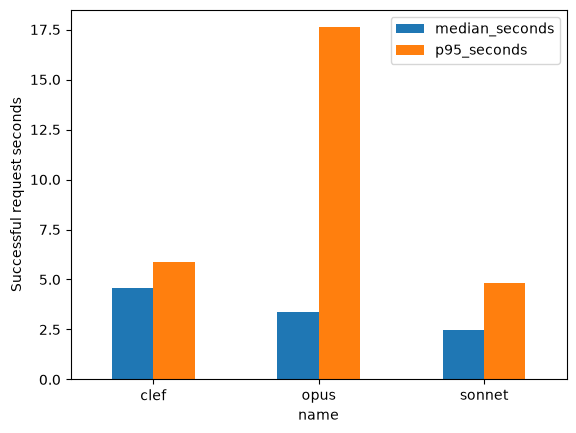

In [6]:
measured["valid"] = measured["status"].eq("ok") & measured["score"].between(
    0, 1
)
valid = measured[measured["valid"]]
operations = measured.groupby("name").agg(
    attempted=("valid", "size"), valid=("valid", "sum")
)
operations["success_rate"] = operations["valid"] / operations["attempted"]
operations["median_seconds"] = valid.groupby("name")["latency_seconds"].median()
operations["p95_seconds"] = valid.groupby("name")["latency_seconds"].quantile(
    0.95
)
display(operations)
display(measured.groupby(["name", "status"]).size().to_frame("calls"))
operations[["median_seconds", "p95_seconds"]].plot.bar(
    rot=0, ylabel="Successful request seconds"
)
plt.show()

### Clef was not faster in the typical request

Clef's median successful call took **4.55 seconds**, versus **3.40 for Opus** and **2.45 for Sonnet**: about 1.34x and 1.86x as long. Its tail was more favorable than Opus's: **p95 5.89 seconds** versus **17.60**, though Sonnet still had the lowest p95 at **4.85 seconds**. Local inference removed a remote API hop but did not make the median call faster on this setup. These distributions use each model's successful calls, not matched-pair timing or a controlled hardware comparison.

**Clef completed all 300 calls; this is not evidence that the hosted models were less capable judges.** Opus returned 281 valid scores and Sonnet 282. One Opus request failed with HTTP 503, and each hosted model lost its final 18 calls to an expired Snowflake session. Those 36 authentication failures are a serving issue to fix before deployment, not reasoning or score-format errors. No failed calls were retried or converted into bad scores.

For the quality analysis that follows, we keep only successful matched pairs. This avoids comparing different inputs across judges, but it cannot remove possible bias from missing late-run observations.

## Human alignment: low error is not the whole story

SummEval expert consistency ratings are normalized from 1-5 to 0-1. **MAE** measures the average absolute gap from experts (lower is better); **Spearman correlation** measures whether judges rank summaries in the same order as experts (higher is better). The fixed pass threshold is 0.75, corresponding to 4 out of 5. A good rank correlation does not mean the same numerical threshold is safe for every judge.

The next tables compare identical successful example/trial pairs across models and show each trial separately. Multiple summaries from one article and repeated judgments are dependent observations; these descriptive results do not establish statistical significance. No prompt or calibrator was fitted on the held-out labels.

In [7]:
paired = valid.pivot(
    index=["example_id", "article_id", "repeat", "true_label"],
    columns="name",
    values="score",
)
paired = paired.reindex(columns=list(metadata["models"]))
paired = paired.dropna().reset_index()
print(f"Common successful example/trial pairs: {len(paired)}")
if paired.empty:
    raise ValueError("No complete panels; inspect the failure table first.")
reports = {
    (model, repeat): AlignmentReport(
        predicted_scores=rows[model].tolist(),
        true_labels=rows["true_label"].tolist(),
        examples=rows.to_dict(orient="records"),
        threshold=THRESHOLD,
    )
    for repeat, rows in paired.groupby("repeat")
    for model in metadata["models"]
}
trial_summaries = [
    report.to_dataframe()["summary"].assign(model=model, trial=repeat + 1)
    for (model, repeat), report in reports.items()
]
display(pd.concat(trial_summaries, ignore_index=True))
model_report = CrossModelAlignmentReport(
    names=list(metadata["models"]),
    scores=[paired[model].tolist() for model in metadata["models"]],
    expected=paired["true_label"].tolist(),
)
display(pd.DataFrame(model_report.ground_truth_metrics()).T)
display(
    pd.DataFrame(
        model_report.spearman,
        index=model_report.names,
        columns=model_report.names,
    )
)
labels = measured.drop_duplicates("example_id")["true_label"]
display(labels.describe().to_frame("expert_consistency"))

Common successful example/trial pairs: 281


,metric,value,model,trial
0,MAE,0.136294,clef,1
1,Spearman correlation,0.530017,clef,1
2,Kendall's tau,0.425274,clef,1
3,Cohen's kappa at 0.75,0.346774,clef,1
4,Brier score,0.036840,clef,1
5,AUC,0.869663,clef,1
6,MAE,0.085017,opus,1
7,Spearman correlation,0.668469,opus,1
8,Kendall's tau,0.623889,opus,1
9,Cohen's kappa at 0.75,0.562826,opus,1


,mae,spearman,kendall
clef,0.133924,0.524590,0.421670
opus,0.086892,0.653247,0.609148
sonnet,0.088968,0.624629,0.581644


,clef,opus,sonnet
clef,1.000000,0.718392,0.710382
opus,0.718392,1.000000,0.946188
sonnet,0.710382,0.946188,1.000000


,expert_consistency
count,100.000000
mean,0.910833
std,0.225125
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


### The hosted judges agreed more closely with experts

Across the **281 matched example/trial pairs**, Clef's MAE was **0.134** and Spearman correlation **0.525**, compared with **0.087 / 0.653 for Opus** and **0.089 / 0.625 for Sonnet**. Clef's absolute error was roughly 50% higher than either hosted judge's. Each trial shows the same direction, although the paired cohort shrinks from 99 and 100 summaries in the first two trials to 82 in the third after the session expires.

The sample is easy to flatter with MAE alone: **77 of the 100 summaries have the maximum expert rating**, and the mean label is 0.911. Predicting 1.0 for every matched row would produce an MAE of about 0.089, yet distinguish no good summaries from bad ones. Read the error, rank correlation, threshold diagnostics, and worst misses together rather than treating a small MAE as sufficient evidence of a useful judge.

**Next: do their numerical scores mean the same thing?** The native `AlignmentReport` plots below show the first trial (99 matched summaries); all three trials are summarized above. On the calibration chart, points on the diagonal match the experts' average rating in that score bin. The histograms and bin counts show where we actually have evidence.

clef


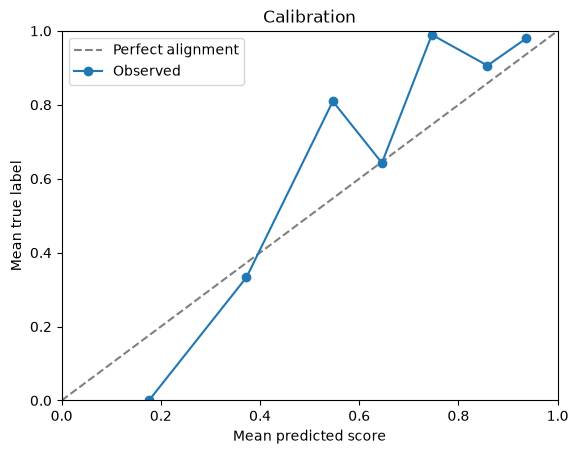

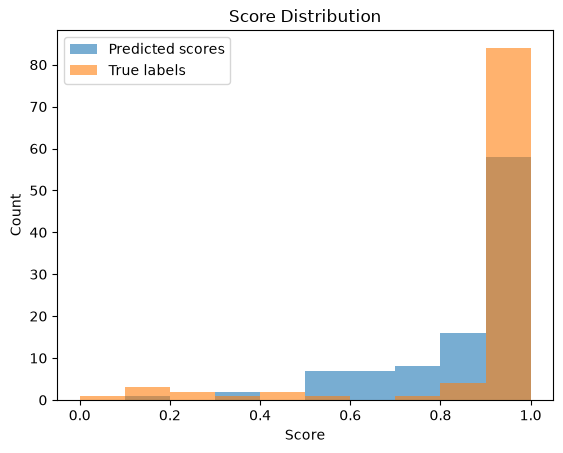

,bin,bin_lower,bin_upper,count,mean_predicted_score,mean_true_label
0,0,0.0,0.1,0,NaN,NaN
1,1,0.1,0.2,1,0.175984,0.000000
2,2,0.2,0.3,0,NaN,NaN
3,3,0.3,0.4,2,0.372751,0.333333
4,4,0.4,0.5,0,NaN,NaN
5,5,0.5,0.6,7,0.546800,0.809524
6,6,0.6,0.7,7,0.645777,0.642857
7,7,0.7,0.8,8,0.746424,0.989583
8,8,0.8,0.9,16,0.858524,0.906250
9,9,0.9,1.0,58,0.936815,0.979885


opus


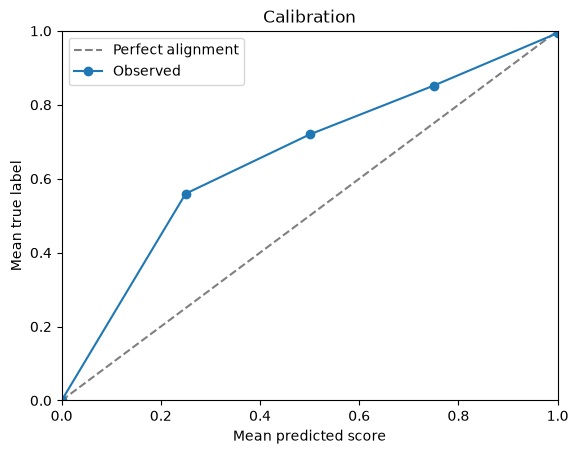

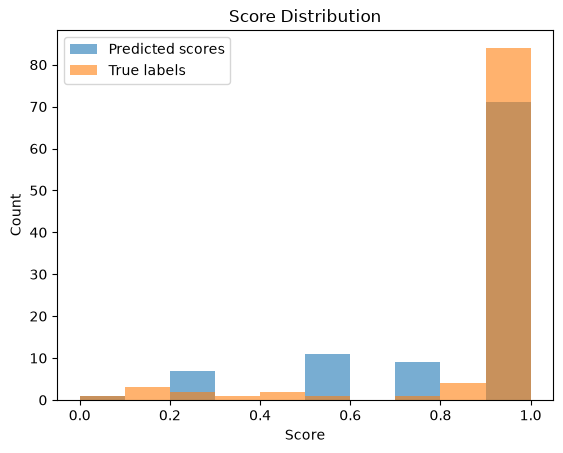

,bin,bin_lower,bin_upper,count,mean_predicted_score,mean_true_label
0,0,0.0,0.1,1,0.00,0.000000
1,1,0.1,0.2,0,NaN,NaN
2,2,0.2,0.3,7,0.25,0.559524
3,3,0.3,0.4,0,NaN,NaN
4,4,0.4,0.5,0,NaN,NaN
5,5,0.5,0.6,11,0.50,0.719697
6,6,0.6,0.7,0,NaN,NaN
7,7,0.7,0.8,9,0.75,0.851852
8,8,0.8,0.9,0,NaN,NaN
9,9,0.9,1.0,71,1.00,0.994131


sonnet


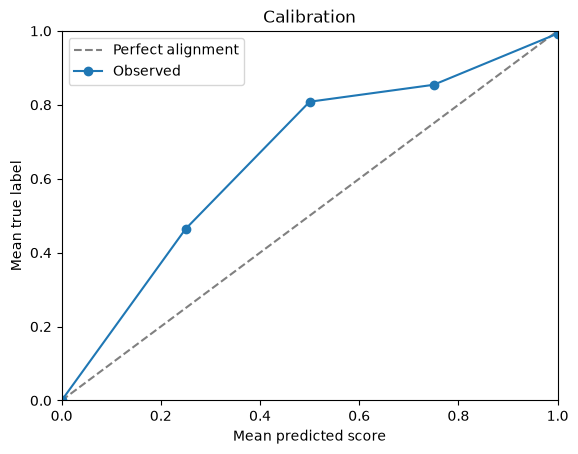

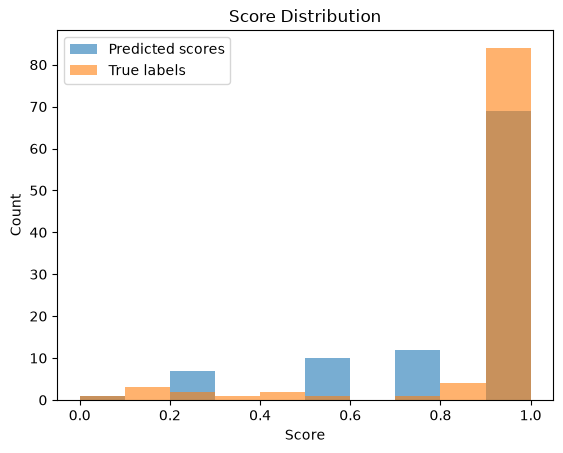

,bin,bin_lower,bin_upper,count,mean_predicted_score,mean_true_label
0,0,0.0,0.1,1,0.00,0.000000
1,1,0.1,0.2,0,NaN,NaN
2,2,0.2,0.3,7,0.25,0.464286
3,3,0.3,0.4,0,NaN,NaN
4,4,0.4,0.5,0,NaN,NaN
5,5,0.5,0.6,10,0.50,0.808333
6,6,0.6,0.7,0,NaN,NaN
7,7,0.7,0.8,12,0.75,0.854167
8,8,0.8,0.9,0,NaN,NaN
9,9,0.9,1.0,69,1.00,0.992754


In [8]:
# Native plots for the first available trial; every trial is summarized above.
first_trial = int(paired["repeat"].min())
for model in metadata["models"]:
    print(model)
    figures = reports[(model, first_trial)].plot()
    plt.show()
    display(reports[(model, first_trial)].to_dataframe()["calibration"])

### Calibration verdict: neither a smooth score nor a good rank is enough

**The curves do not support calling Clef well-calibrated across the observed range.** In the first trial, its 0.7-0.8 bin contained eight summaries: mean prediction 0.746 versus mean expert rating 0.990. Its 0.5-0.6 bin contained seven: 0.547 versus 0.810. Points above the diagonal mean the judge rates those summaries lower than experts do. Even its most populated bin (58 summaries, 0.9-1.0) averaged 0.937 versus 0.980.

The hosted judges matched experts closely at their highest score: Opus's 71 scores of 1.0 averaged 0.994 in expert ratings, and Sonnet's 69 averaged 0.993. **They were not well-aligned everywhere either.** Opus's 11 scores of 0.5 averaged 0.720 from experts; Sonnet's ten averaged 0.808. Small bin counts and the high-score-heavy dataset limit conclusions about the rest of the scale. Empty bins provide no evidence.

Clef returns a probability-weighted ordinal score; Claude is prompted for an integer rating. Normalizing both to 0-1 makes the scales comparable but does not make their values probabilities that a summary is correct. Here, 'calibration' means agreement with expert ratings. No calibration mapping was trained, and these plots do not validate a production pass/fail threshold. The next tables show why inspecting individual misses still matters.

In [9]:
for model in metadata["models"]:
    print(model, "largest absolute errors, first available trial")
    misses = reports[(model, first_trial)].to_dataframe()["worst_misses"]
    display(misses.head(5))

clef largest absolute errors, first available trial


,index,predicted_score,true_label,absolute_error,example_id,article_id,repeat,example_true_label,clef,opus,sonnet
0,26,0.916574,0.166667,0.749907,dm-test-02c955067d00f38b6978b805d5a8701a787f78...,dm-test-02c955067d00f38b6978b805d5a8701a787f78ac,0,0.166667,0.916574,0.75,0.75
1,51,0.881909,0.166667,0.715242,dm-test-2cfc33d01364162579f46b2764914a03a29453...,dm-test-2cfc33d01364162579f46b2764914a03a29453ce,0,0.166667,0.881909,0.25,0.25
2,56,0.519329,1.000000,0.480671,dm-test-4fb64a2298e18626db776fccf834be87388827...,dm-test-4fb64a2298e18626db776fccf834be87388827e0,0,1.000000,0.519329,0.25,0.25
3,80,0.502309,0.916667,0.414357,dm-test-97bbda7ec22a736cd174b51513c72a6372d13d...,dm-test-97bbda7ec22a736cd174b51513c72a6372d13d35,0,0.916667,0.502309,0.25,0.50
4,1,0.586416,1.000000,0.413584,cnn-test-b8b6e729fff27c4eef87887e61d3448de9c06...,cnn-test-b8b6e729fff27c4eef87887e61d3448de9c063f6,0,1.000000,0.586416,0.50,0.50


opus largest absolute errors, first available trial


,index,predicted_score,true_label,absolute_error,example_id,article_id,repeat,example_true_label,clef,opus,sonnet
0,15,0.25,1.000000,0.750000,cnn-test-e49792c337d3f4c13e22f710efa44cf6a4e59...,cnn-test-e49792c337d3f4c13e22f710efa44cf6a4e59aba,0,1.000000,0.659582,0.25,0.50
1,56,0.25,1.000000,0.750000,dm-test-4fb64a2298e18626db776fccf834be87388827...,dm-test-4fb64a2298e18626db776fccf834be87388827e0,0,1.000000,0.519329,0.25,0.25
2,80,0.25,0.916667,0.666667,dm-test-97bbda7ec22a736cd174b51513c72a6372d13d...,dm-test-97bbda7ec22a736cd174b51513c72a6372d13d35,0,0.916667,0.502309,0.25,0.50
3,26,0.75,0.166667,0.583333,dm-test-02c955067d00f38b6978b805d5a8701a787f78...,dm-test-02c955067d00f38b6978b805d5a8701a787f78ac,0,0.166667,0.916574,0.75,0.75
4,1,0.50,1.000000,0.500000,cnn-test-b8b6e729fff27c4eef87887e61d3448de9c06...,cnn-test-b8b6e729fff27c4eef87887e61d3448de9c063f6,0,1.000000,0.586416,0.50,0.50


sonnet largest absolute errors, first available trial


,index,predicted_score,true_label,absolute_error,example_id,article_id,repeat,example_true_label,clef,opus,sonnet
0,56,0.25,1.000000,0.750000,dm-test-4fb64a2298e18626db776fccf834be87388827...,dm-test-4fb64a2298e18626db776fccf834be87388827e0,0,1.000000,0.519329,0.25,0.25
1,74,0.25,0.916667,0.666667,dm-test-6c1341bedf92a304318545fbf1aad88651de79...,dm-test-6c1341bedf92a304318545fbf1aad88651de7909,0,0.916667,0.680519,0.50,0.25
2,26,0.75,0.166667,0.583333,dm-test-02c955067d00f38b6978b805d5a8701a787f78...,dm-test-02c955067d00f38b6978b805d5a8701a787f78ac,0,0.166667,0.916574,0.75,0.75
3,1,0.50,1.000000,0.500000,cnn-test-b8b6e729fff27c4eef87887e61d3448de9c06...,cnn-test-b8b6e729fff27c4eef87887e61d3448de9c063f6,0,1.000000,0.586416,0.50,0.50
4,15,0.50,1.000000,0.500000,cnn-test-e49792c337d3f4c13e22f710efa44cf6a4e59...,cnn-test-e49792c337d3f4c13e22f710efa44cf6a4e59aba,0,1.000000,0.659582,0.25,0.50


### Worst misses reveal what an average hides

Clef's largest first-trial miss scored a summary **0.917 when experts scored it 0.167**. That would pass our fixed 0.75 threshold despite the low expert rating. Clef is not simply 'too strict': although it assigns lower scores than experts to many high-rated summaries, it can also give a high score to a poorly rated one.

The hosted judges also made large errors. On one shared example both scored 0.25 against an expert score of 1.0. Stronger aggregate agreement is not permission to treat a judge as ground truth. The table retains public benchmark IDs so these disagreements can be traced back to the article and summary for review; this notebook does not adjudicate whether the model or the human label was right in each case.

## Repeatability, a median jury, and usage

Now we separate **stability** (does a judge repeat its score?) from **alignment** (does that score match experts?). We replay the recorded scores through native TruLens `Jury`; this makes no additional model calls. Repeated-call comparisons require all three trials to succeed for every model on a summary.

`reliability.score_std` measures the score spread. `reliability.flip_rate` measures the fraction of votes disagreeing with the majority pass/fail decision at 0.75, not the fraction of examples that flipped at least once. A model can change its numerical score without crossing that threshold.

The median panel combines Clef, Opus, and Sonnet on complete example/trial pairs. Its alignment is measured, but its live execution latency is not. The usage table counts only calls that reported usage; missing usage is not assumed to be free. After the tables, we interpret whether the extra calls bought better judgments and what we can say about cost.

In [10]:
class RecordedJudge:
    """Replay measured scores so native Jury analysis needs no new calls."""

    def __init__(self, name, score):
        self.model_engine = name
        self.value = score

    def score(self, **kwargs):
        return self.value


repeat_results = []
for model in metadata["models"]:
    for example_id, rows in paired.groupby("example_id"):
        if len(rows) != metadata["repeats"]:
            continue
        repeated = Jury(
            [
                RecordedJudge(model, score)
                for score in rows.sort_values("repeat")[model]
            ],
            method="score",
            max_workers=1,
            threshold=THRESHOLD,
        )
        _, reliability = repeated()
        repeat_results.append({
            "model": model,
            "example_id": example_id,
            **reliability,
        })
reliability = pd.DataFrame(repeat_results)
if not reliability.empty:
    display(reliability.groupby("model").size().to_frame("complete_cohorts"))
    display(
        reliability.groupby("model")[
            [
                "reliability.score_std",
                "reliability.flip_rate",
                "reliability.outcome_entropy",
            ]
        ].mean()
    )
else:
    print("No complete repeated-trial cohorts.")

jury_scores = []
for row in paired.to_dict(orient="records"):
    jury = Jury(
        [RecordedJudge(model, row[model]) for model in metadata["models"]],
        method="score",
        aggregation="median",
        threshold=THRESHOLD,
    )
    score, _ = jury()
    jury_scores.append(score)
jury_report = AlignmentReport(
    jury_scores, paired["true_label"].tolist(), threshold=THRESHOLD
)
display(jury_report.to_dataframe()["summary"])
usage = pd.DataFrame([
    {"model": row["name"], **row["usage"]}
    for row in measured.to_dict(orient="records")
    if isinstance(row.get("usage"), dict)
])
if not usage.empty:
    display(usage.groupby("model").sum(numeric_only=True))
    display(usage.groupby("model").size().to_frame("calls_with_usage"))
print(metadata["cost_note"])

,complete_cohorts
model,
clef,81
opus,81
sonnet,81


,reliability.score_std,reliability.flip_rate,reliability.outcome_entropy
model,,,
clef,0.000000,0.000000,0.000000
opus,0.005820,0.004115,0.011337
sonnet,0.013095,0.000000,0.000000


,metric,value
0,MAE,0.086497
1,Spearman correlation,0.637780
2,Kendall's tau,0.591895
3,Cohen's kappa at 0.75,0.500262
4,Brier score,0.034556
5,AUC,0.946852


,input_tokens,output_tokens,cache_read_input_tokens,cache_creation_input_tokens
model,,,,
clef,245334,0,0,0
opus,306942,14957,0,0
sonnet,308367,42794,0,0


,calls_with_usage
model,
clef,300
opus,281
sonnet,282


Cortex USD unknown. Local API charge excludes hardware/electricity.


### Stable judgments did not necessarily agree with humans

There are **81 summaries with complete three-trial cohorts for all three judges**. On those summaries, Clef returned identical scores (mean score standard deviation 0). Opus's mean standard deviation was 0.0058 and Sonnet's was 0.0131. Opus's mean majority-disagreement rate was 0.41%; Clef and Sonnet had no threshold disagreements. Sonnet's nonzero score variation alongside zero flips illustrates why both measures matter.

This establishes repeatability only for three calls under these serving settings, without a temperature override. It does not establish stability on other tasks or after model updates. Clef's larger human-alignment error shows why a consistently repeated answer can still be wrong.

**The median jury did not establish a useful improvement over Opus alone.** Its MAE was 0.0865 versus Opus's 0.0869, a tiny descriptive difference, while its Spearman correlation was lower (0.638 versus 0.653). A live panel needs all three judgments. These results do not justify that added inference work for this task, and no live-jury latency or dollar savings were measured.

## Cost: no API charge is not the same as lower total cost

**Clef avoids a provider API charge because these calls ran locally. We cannot conclude it was cheaper overall.** The run did not measure electricity, hardware amortization, or utilization, and it did not retrieve the Snowflake bill or applicable Cortex rates. Applying direct Anthropic prices to Cortex calls would give the wrong billing basis.

Reported usage was 245,334 input tokens for Clef; 306,942 input and 14,957 output tokens for Opus; and 308,367 input and 42,794 output tokens for Sonnet. Usage coverage was 300, 281, and 282 calls respectively. Clef's typed decision response reports zero output tokens in this snapshot; that does not mean inference consumed no compute. Token counts across different model tokenizers are not equivalent units of work or dollars.

A useful follow-up would compare **cost per acceptable judgment** at a validated quality threshold: actual Cortex charges versus local operating cost, including retries and utilization. Until then, the defensible finding is 'no local provider API charge,' not 'Clef is cheaper' or a claimed savings percentage.

## What would we deploy after this experiment?

**Sonnet is the stronger starting candidate when response time matters:** it was fastest at both the median and p95 here, with human-alignment error close to Opus. **Opus is the stronger starting candidate when agreement with experts matters most:** it had the lowest individual-judge MAE and highest rank correlation, with a much slower p95. The small Opus-Sonnet quality gap is not a statistically established ranking, and neither recommendation includes a dollar-cost advantage.

**Clef is a candidate when local execution is a requirement, not a demonstrated drop-in replacement.** It was repeatable and completed all calls, but took longer than both hosted judges at the median and showed weaker human alignment and substantial calibration gaps. Before using it to accept or reject summaries, inspect its worst misses, choose or calibrate a decision threshold on separate development/validation data, then confirm on a fresh held-out set. This experiment does not show that repeating Clef or adding it to a jury fixes its errors.

The reusable TruLens workflow is the lesson: measure operational failures, speed, human alignment, score calibration, repeatability, and actual cost separately. A judge must meet the application's quality requirement before a latency or price advantage makes it a replacement.

## Reproduce

Install the dependencies listed in [README.md](README.md), pull `clef` with Ollama 0.35.1 or newer, and configure `SNOWFLAKE_CONNECTION_NAME`. Set `RUN_LIVE=True` and execute the live cells. They use native `Jury.repeated` and save `live_results.json`; leave live mode off to reproduce the included analysis without new charges.

The included snapshot comes from the earlier interleaved execution of the same frozen dataset, rubric, model settings, and three-trial design. Its Cortex scoring used a strict terminal-JSON parser; the simplified live example uses TruLens `generate_score` parsing. These are documented as different parser configurations, not asserted to be byte-identical reruns. Do not mix outputs from the two runs.

No calibrator was fitted on the held-out labels. Public benchmarks may overlap model training. Summaries from one article and repeated calls are dependent observations. Calibration curves describe ordinal score agreement, not event probabilities; results apply only to this task and deployment.